In [26]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler 
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

plt.rc('font',family='D2CodingLigature Nerd Font')
# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시

## 예측과 성능평가

|컬럼명|데이터타입|예시 및 세부 내용
|------|----------|------------------
|age|int64|나이(정수)
|workclass|object|고용 유형 (예: Private, Self-emp, Government 등)
|fnlwgt|int64|최종 인구통계 가중치 (Census에서 인구 집단 대표성을 반영하기 위한 가중치)
|education|object|교육 수준 (예: Bachelors, HS-grad, Masters 등)
|education.num|int64|교육 년수 (교육 수준을 숫자로 변환, 예: 고졸 = 9, 학사 = 13)
|marital.status|object|결혼 상태 (예: Married, Never-married, Divorced 등)
|occupation|object|직업 (예: Tech-support, Craft-repair, Sales 등)
|relationship|object|가구주와의 관계 (예: Husband, Wife, Unmarried 등)
|race|object|인종 (예: White, Asian-Pac-Islander, Black 등)
|sex|object|성별 (Male/Female)
|capital.gain|int64|자본 소득 (투자나 자산 판매로 얻은 수익)
|capital.loss|int64|자본 손실 (투자나 자산 판매로 인한 손실)
|hours.per.week|int64|주당 근무 시간
|native.country|object|출신 국가
|income|object|연소득 ( <=50K : 연 소득이 50,000달러 이하)

### 전처리 -> 모델 생성 및 학습 -> 예측 및 성능 평가

In [2]:
df = pd.read_csv('../../data/adult.csv', encoding='utf-8')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


### 타겟 변수 전처리

In [3]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [4]:
df['income'].value_counts(normalize = True)

income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64

In [5]:
df['income'] = np.where(df['income'] == '>50K', 'high', 'low')

# income 컬럼에서 >50K 값을 'high'로 변경.
# 나머지 값(<=50K)은 'low'로 변경.
# 즉, income이 high 또는 low 두 개의 값만 갖게 됨.

In [6]:
## 데이터 확인
print(df['income'].unique())

['low' 'high']


In [7]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,low
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,low
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,low
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,low
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,low


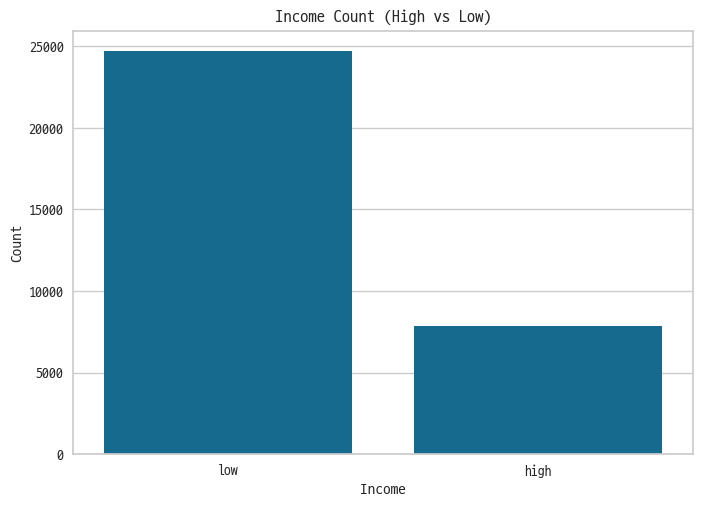

In [8]:
sns.countplot(data=df, x='income')
plt.xlabel('Income')
plt.ylabel('Count')
plt.title('Income Count (High vs Low)')
plt.show()

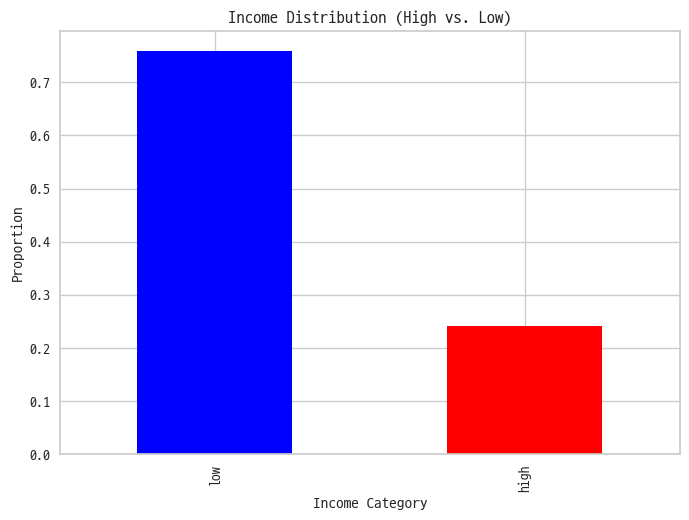

In [9]:
df['income'].value_counts(normalize=True).plot(kind='bar', color=['blue', 'red'])
plt.xlabel('Income Category')
plt.ylabel('Proportion')
plt.title('Income Distribution (High vs. Low)')
plt.show()

#### 불필요한 변수 제거

In [10]:
df = df.drop(columns = 'fnlwgt')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   education       32561 non-null  object
 3   education.num   32561 non-null  int64 
 4   marital.status  32561 non-null  object
 5   occupation      32561 non-null  object
 6   relationship    32561 non-null  object
 7   race            32561 non-null  object
 8   sex             32561 non-null  object
 9   capital.gain    32561 non-null  int64 
 10  capital.loss    32561 non-null  int64 
 11  hours.per.week  32561 non-null  int64 
 12  native.country  32561 non-null  object
 13  income          32561 non-null  object
dtypes: int64(5), object(9)
memory usage: 3.5+ MB


#### 성별 데이터 전처리

In [11]:
df_tmp = df[['sex']]
df_tmp

,sex
0,Female
1,Female
2,Female
3,Female
4,Female
...,...
32556,Male
32557,Female
32558,Male
32559,Female


In [12]:
df_tmp['sex'].value_counts()

sex
Male      21790
Female    10771
Name: count, dtype: int64

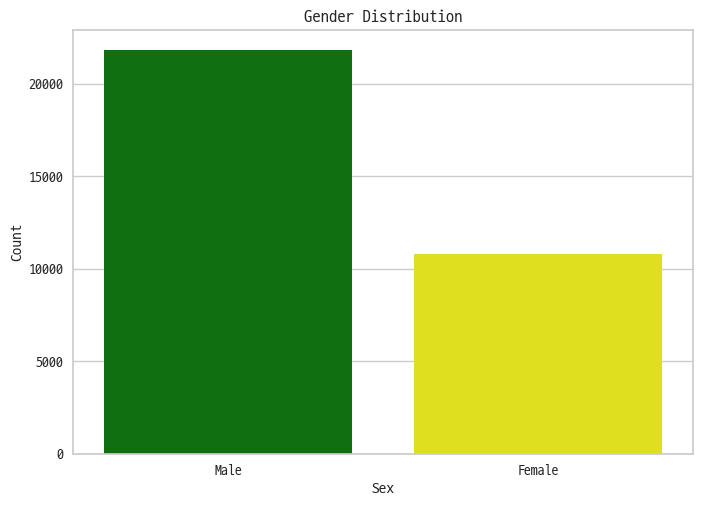

In [13]:
# df_tmp['sex'].value_counts().plot(kind='bar', color=['blue', 'pink'])
sns.countplot(data=df_tmp, x='sex', order=['Male', 'Female'], palette=['green', 'yellow'])
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.show()

In [14]:
df_tmp = pd.get_dummies(df_tmp)     ## 원-핫 인코딩
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   sex_Female  32561 non-null  bool 
 1   sex_Male    32561 non-null  bool 
dtypes: bool(2)
memory usage: 63.7 KB


In [15]:
df_tmp.tail()

,sex_Female,sex_Male
32556,False,True
32557,True,False
32558,False,True
32559,True,False
32560,False,True


#### 원핫인코딩

In [16]:
target = df['income']   # 종속변수 income을 추출하여 저장해 두기

In [17]:
df = df.drop(columns='income')  # income 항목 제거
df = pd.get_dummies(df) # 원핫인코딩
df

,age,education.num,capital.gain,capital.loss,hours.per.week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,9,0,4356,40,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,82,9,0,4356,18,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,66,10,0,4356,40,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,54,4,0,3900,40,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,41,10,0,3900,40,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,10,0,0,40,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
32557,27,12,0,0,38,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
32558,40,9,0,0,40,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
32559,58,9,0,0,40,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False


In [18]:
df['income'] = target
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Columns: 108 entries, age to income
dtypes: bool(102), int64(5), object(1)
memory usage: 4.7+ MB


In [19]:
df.head(3)

,age,education.num,capital.gain,capital.loss,hours.per.week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,income
0,90,9,0,4356,40,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,low
1,82,9,0,4356,18,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,low
2,66,10,0,4356,40,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,low


### 데이터 분할

In [21]:
df_train, df_test = train_test_split(df, test_size=0.3, stratify=df['income'], random_state=0)

In [24]:
# train
df_train.shape

(22792, 108)

In [ ]:
# test
df_test.shape

(9769, 108)

In [23]:
# train
df_train['income'].value_counts(normalize = True)

income
low     0.75917
high    0.24083
Name: proportion, dtype: float64

In [25]:
# test
df_test['income'].value_counts(normalize = True)

income
low     0.759238
high    0.240762
Name: proportion, dtype: float64

### 의사결정트리 모델

In [28]:
from sklearn import tree
clf = tree.DecisionTreeClassifier( random_state = 1234, max_depth = 7) 

In [29]:
## 모델 생성
train_x = df_train.drop(columns = 'income')
train_y = df_train['income']

model = clf.fit(X = train_x, y = train_y)

In [30]:
# 훈련용 컬럼 리스트 (독립변수들) 저장
trained_columns = train_x.columns.tolist()

[Text(0.5315315315315315, 0.9375, 'x[32] <= 0.5\ngini = 0.366\nsamples = 22792\nvalue = [5489, 17303]'),
 Text(0.2911036036036036, 0.8125, 'x[2] <= 7139.5\ngini = 0.125\nsamples = 12269\nvalue = [823, 11446]'),
 Text(0.41131756756756754, 0.875, 'True  '),
 Text(0.19481981981981983, 0.6875, 'x[1] <= 12.5\ngini = 0.095\nsamples = 12040\nvalue = [602, 11438]'),
 Text(0.11711711711711711, 0.5625, 'x[3] <= 2391.5\ngini = 0.051\nsamples = 9657\nvalue = [251, 9406]'),
 Text(0.07207207207207207, 0.4375, 'x[4] <= 40.5\ngini = 0.048\nsamples = 9632\nvalue = [235, 9397]'),
 Text(0.036036036036036036, 0.3125, 'x[3] <= 2218.5\ngini = 0.029\nsamples = 7896\nvalue = [117, 7779]'),
 Text(0.018018018018018018, 0.1875, 'x[0] <= 33.5\ngini = 0.028\nsamples = 7879\nvalue = [112, 7767]'),
 Text(0.009009009009009009, 0.0625, 'gini = 0.008\nsamples = 4629\nvalue = [18, 4611]'),
 Text(0.02702702702702703, 0.0625, 'gini = 0.056\nsamples = 3250\nvalue = [94, 3156]'),
 Text(0.05405405405405406, 0.1875, 'x[3] <= 

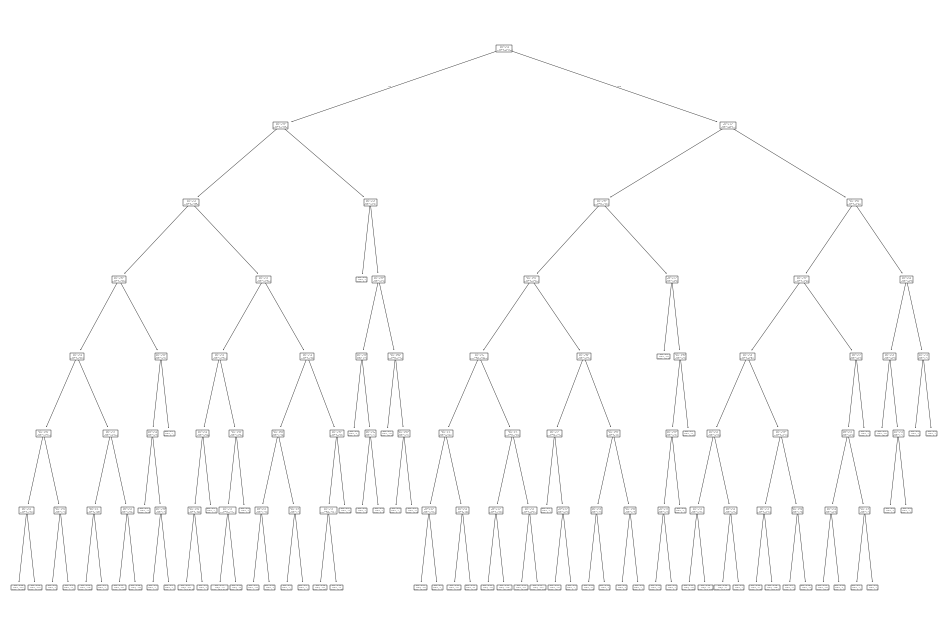

In [32]:
plt.rcParams.update({'figure.dpi'     : '100',     # 해상도 설정
                     'figure.figsize' : [12, 8]})  # 그래프 크기 설정
tree.plot_tree(model)

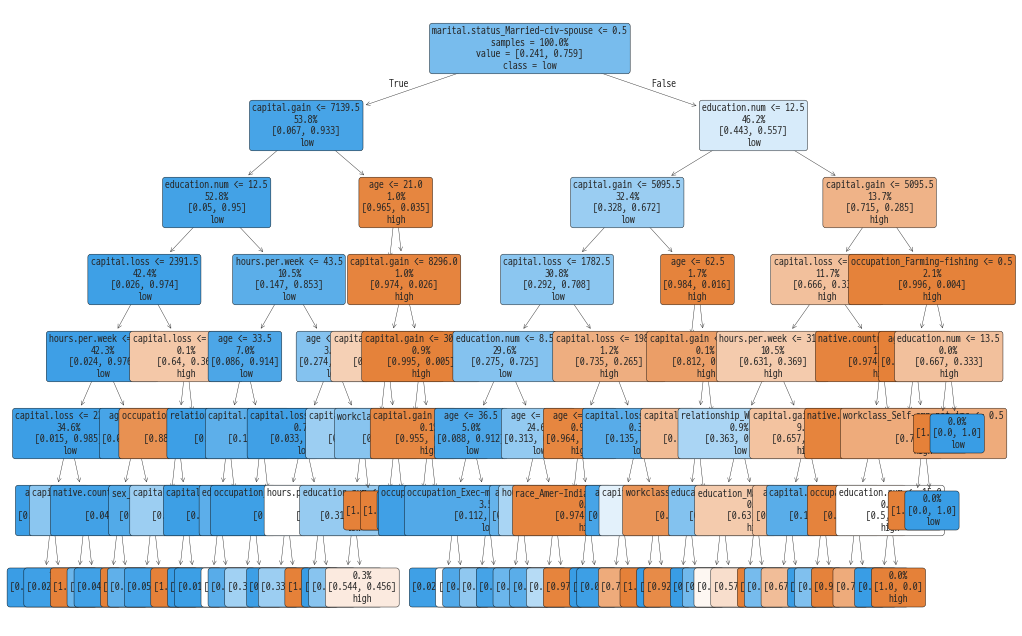

In [35]:
tree.plot_tree(model,
               feature_names = train_x.columns,  # 예측 변수명
               class_names = ['high', 'low'],    # 타겟 변수 클래스, 알파벳순
               proportion = True,                # 비율 표기
               filled = True,                    # 색칠
               rounded = True,                   # 둥근 테두리
               impurity = False,                 # 불순도 표시
               label = 'root',                   # label 표시 위치
               fontsize = 7);                   # 글자 크기
plt.show()

In [36]:
### 모델 검증하기
test_x = df_test.drop(columns = 'income')  
test_y = df_test['income']

In [37]:
# 테스트 데이터의 검증한 예측값 구하기
df_test['pred'] = model.predict(test_x)
df_test

,age,education.num,capital.gain,capital.loss,hours.per.week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,income,pred
28810,47,9,0,0,40,False,False,False,False,True,...,False,False,False,False,False,True,False,False,low,low
14208,28,10,0,0,65,False,False,True,False,False,...,False,False,False,False,False,True,False,False,low,low
5134,90,9,0,0,40,False,False,False,False,True,...,False,False,False,False,False,True,False,False,low,low
16862,38,9,0,0,30,False,False,False,False,True,...,False,False,False,False,False,True,False,False,low,low
2390,60,10,7688,0,50,False,False,False,False,False,...,False,False,False,False,False,True,False,False,high,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29689,35,9,0,0,40,False,False,False,False,True,...,False,False,False,False,False,True,False,False,high,low
31442,55,13,0,0,8,False,False,False,False,False,...,False,False,False,False,False,True,False,False,low,high
24131,61,9,0,0,40,False,False,False,False,True,...,False,False,False,False,False,True,False,False,low,low
29762,43,10,0,0,40,False,False,False,False,False,...,False,False,False,False,False,True,False,False,low,low


### 성능 평가

In [38]:
#### confusion matrix 만들기

from sklearn.metrics import confusion_matrix
conf_mat = confusion_matrix(y_true = df_test['income'],  # 실제값
                            y_pred = df_test['pred'],    # 예측값
                            labels = ['high', 'low'])    # 클래스 배치 순서
conf_mat

array([[1255, 1097],
       [ 329, 7088]])

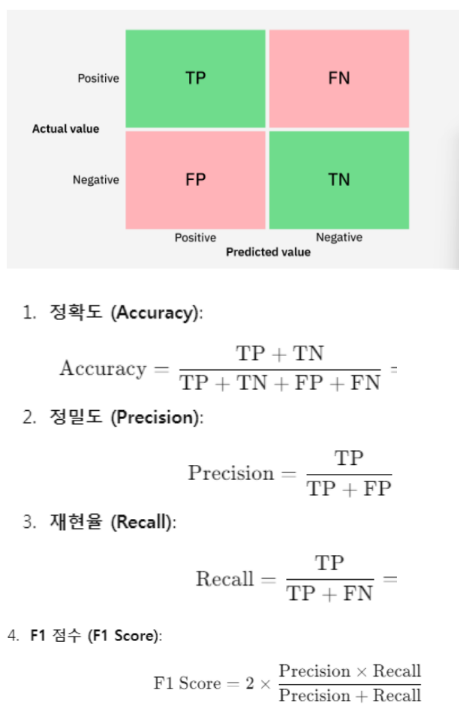

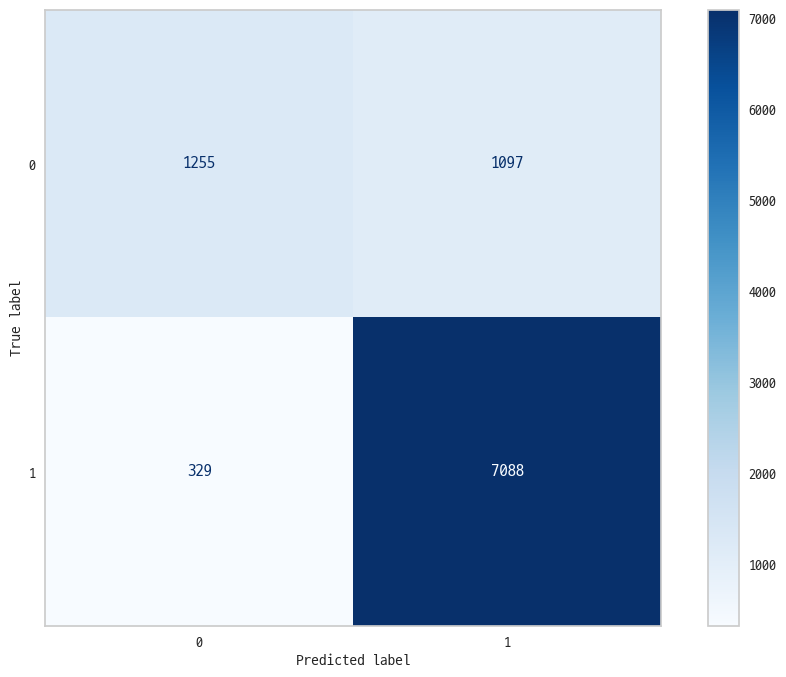

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

p = ConfusionMatrixDisplay(confusion_matrix = conf_mat)
p.plot(cmap = 'Blues')  
plt.grid(False)
plt.show()

In [40]:
import sklearn.metrics as metrics

## **accuracy** (정확도)
metrics.accuracy_score(y_true = df_test['income'],  # 실제값
                       y_pred = df_test['pred'])    # 예측값

0.8540280479066434

In [41]:
## **precision** (정밀도)
metrics.precision_score(y_true = df_test['income'],  # 실제값
                        y_pred = df_test['pred'],    # 예측값
                        pos_label = 'high')          # 관심 클래스

0.7922979797979798

In [42]:
## **precision** (정밀도)
metrics.precision_score(y_true = df_test['income'],  # 실제값
                        y_pred = df_test['pred'],    # 예측값
                        pos_label = 'low')          # 관심 클래스

0.8659743433109346

In [43]:
## **recall** (재현율)
metrics.recall_score(y_true = df_test['income'],  # 실제값
                     y_pred = df_test['pred'],    # 예측값
                     pos_label = 'high')          # 관심 클래스

0.5335884353741497

In [44]:
## **F1 score**
## 0~1 사이 값, 성능이 높을수록 1에 가까운 값

metrics.f1_score(y_true = df_test['income'],  # 실제값
                 y_pred = df_test['pred'],    # 예측값
                 pos_label = 'high')          # 관심 클래스

0.6377032520325203

### 새로운 데이터로 예측 실행

In [45]:
# 새로운 샘플 (원-핫 인코딩 전)
new_raw = pd.DataFrame([{
    'age': 42,
    'workclass': 'Private',
    'education': 'Bachelors',
    'education.num': 13,
    'marital.status': 'Married-civ-spouse',
    'occupation': 'Exec-managerial',
    'relationship': 'Husband',
    'race': 'White',
    'sex': 'Male',
    'capital.gain': 0,
    'capital.loss': 0,
    'hours.per.week': 45,
    'native.country': 'United-States'
}])

# 원-핫 인코딩 적용 (훈련 데이터와 같은 방식으로)
new_encoded = pd.get_dummies(new_raw)

# 훈련 시 사용한 열 순서로 정렬, 없는 열은 0으로 채움
new_encoded = new_encoded.reindex(columns=trained_columns, fill_value=0)

# 예측
prediction = model.predict(new_encoded)

# 결과 출력
print("예측 소득 수준:", prediction[0])

예측 소득 수준: high
